In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

df = pd.read_csv('../data/crime_features.csv')
print(df.shape)

# Geographic features for clustering
geo = df[['Latitude', 'Longitude']].copy()
scaler = StandardScaler()
geo_scaled = scaler.fit_transform(geo)

(500000, 28)


K=2  Silhouette=0.4514
K=3  Silhouette=0.4276
K=4  Silhouette=0.4142
K=5  Silhouette=0.4036
K=6  Silhouette=0.3993
K=7  Silhouette=0.3979
K=8  Silhouette=0.4058
K=9  Silhouette=0.4073
K=10  Silhouette=0.4153
K=11  Silhouette=0.4108


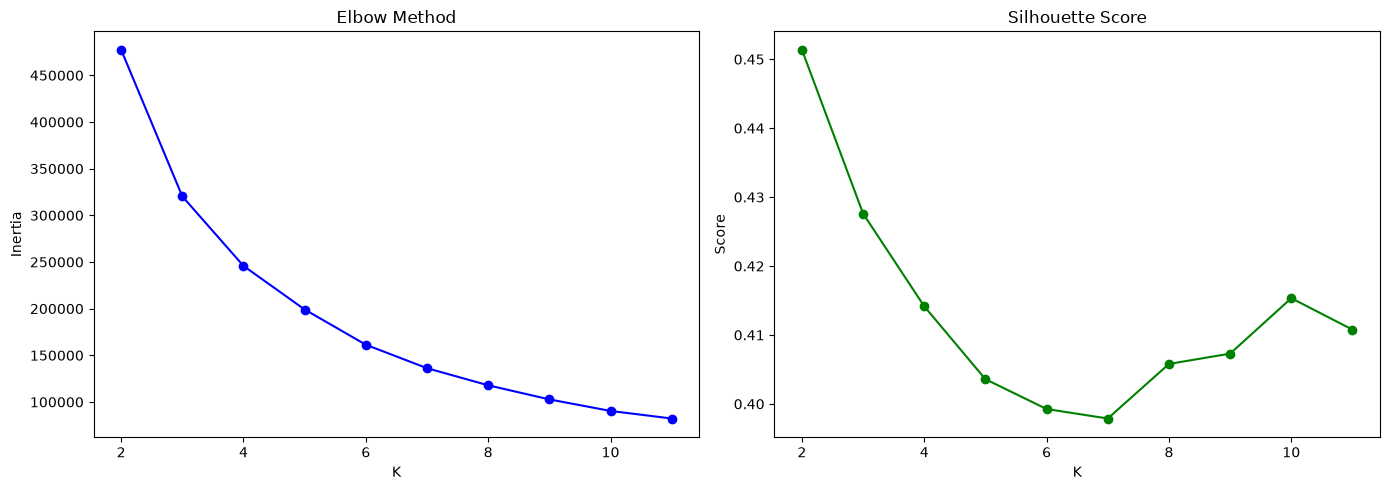

In [2]:
inertias = []
sil_scores = []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(geo_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(geo_scaled, labels, sample_size=10000))
    print(f"K={k}  Silhouette={sil_scores[-1]:.4f}")

# Plot elbow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')

ax2.plot(K_range, sil_scores, 'go-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('K'); ax2.set_ylabel('Score')
plt.tight_layout()
plt.show()

In [3]:
BEST_K = 7  # adjust after seeing the elbow plot

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['KMeans_Cluster'] = km_final.fit_predict(geo_scaled)

print(f"Silhouette Score: {silhouette_score(geo_scaled, df['KMeans_Cluster'], sample_size=10000):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(geo_scaled, df['KMeans_Cluster']):.4f}")
print(df['KMeans_Cluster'].value_counts())

Silhouette Score: 0.4004
Davies-Bouldin Score: 0.8451
KMeans_Cluster
3    97972
4    83501
1    78096
6    75943
0    65296
2    50439
5    48753
Name: count, dtype: int64


In [4]:
db = DBSCAN(eps=0.08, min_samples=50, n_jobs=-1)
df['DBSCAN_Cluster'] = db.fit_predict(geo_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
noise_pct = (df['DBSCAN_Cluster'] == -1).mean() * 100

print(f"Clusters found: {n_clusters}")
print(f"Noise points: {noise_pct:.1f}%")

# Only score non-noise points
mask = df['DBSCAN_Cluster'] != -1
if mask.sum() > 1 and len(df.loc[mask,'DBSCAN_Cluster'].unique()) > 1:
    print(f"Silhouette Score: {silhouette_score(geo_scaled[mask], df.loc[mask,'DBSCAN_Cluster'], sample_size=10000):.4f}")

Clusters found: 8
Noise points: 0.0%
Silhouette Score: 0.0877


In [5]:
# Use a sample for hierarchical (too slow on 500K)
sample_idx = np.random.choice(len(geo_scaled), size=10000, replace=False)
geo_sample = geo_scaled[sample_idx]

hc = AgglomerativeClustering(n_clusters=BEST_K)
hc_labels = hc.fit_predict(geo_sample)

print(f"Silhouette Score: {silhouette_score(geo_sample, hc_labels):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(geo_sample, hc_labels):.4f}")
print(pd.Series(hc_labels).value_counts())

Silhouette Score: 0.3788
Davies-Bouldin Score: 0.8522
1    2219
5    2160
2    1801
0    1505
4    1155
3     754
6     406
Name: count, dtype: int64


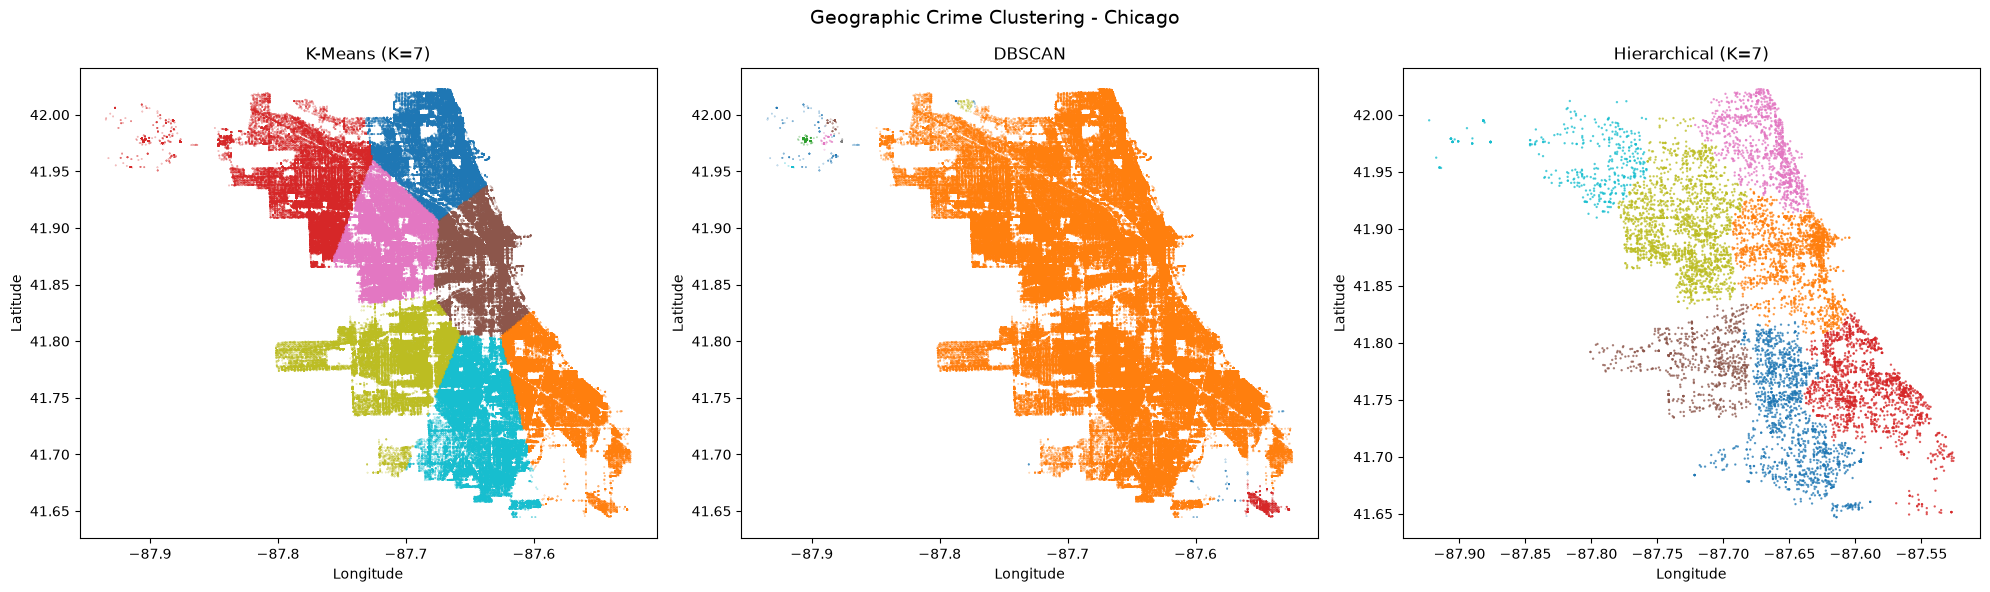

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(df['Longitude'], df['Latitude'], c=df['KMeans_Cluster'], 
                cmap='tab10', s=0.1, alpha=0.5)
axes[0].set_title(f'K-Means (K={BEST_K})')

colors_db = df['DBSCAN_Cluster'].copy()
axes[1].scatter(df['Longitude'], df['Latitude'], c=colors_db,
                cmap='tab10', s=0.1, alpha=0.5)
axes[1].set_title('DBSCAN')

axes[2].scatter(geo['Longitude'].iloc[sample_idx], geo['Latitude'].iloc[sample_idx],
                c=hc_labels, cmap='tab10', s=0.5, alpha=0.7)
axes[2].set_title(f'Hierarchical (K={BEST_K})')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Geographic Crime Clustering - Chicago', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
df.to_csv('../data/crime_clustered.csv', index=False)
print("Saved → data/crime_clustered.csv")

Saved → data/crime_clustered.csv
